# Effectiveness of AI in Computer Science #

## Importing Libraries

In [320]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb as ddb

- Pandas: for reading CSV file and exploratory analysis.
- Matplotlib & Seaborn: for visualization.
- DuckDB: for SQL querying if needed.

In [321]:
import os
print("Files Docker can see right now:")
print(os.listdir('.'))

Files Docker can see right now:
['ai_cs_analysis.ipynb', '.git', '.devcontainer', 'Dockerfile', 'survey_results_public.csv', 'README.md', '.gitignore']


Using `os.listdir` to check what files in the project repository does Docker can see.

## Import and analyze the data

For this project, we used the 2025 Stack Overflow Developer Survey to reference the use of AI by developers around the world.

In [322]:
data = pd.read_csv(r'survey_results_public.csv')
data.head(5)

/tmp/ipykernel_1116/2543645080.py:1: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r'survey_results_public.csv')


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


### Exploratory Data Analysis

In [323]:
data.columns

Index(['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment',
       'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode',
       'LearnCodeAI',
       ...
       'AIAgentOrchestration', 'AIAgentOrchWrite', 'AIAgentObserveSecure',
       'AIAgentObsWrite', 'AIAgentExternal', 'AIAgentExtWrite', 'AIHuman',
       'AIOpen', 'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=172)

The survey has 172 column attributes, so reducing the dimension for the most relevant ones would be necessary.

In [324]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 64.6 MB


In [325]:
data.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
EdLevel                 1042
Employment               852
                       ...  
AIAgentExtWrite        48332
AIHuman                19997
AIOpen                 26651
ConvertedCompYearly    25244
JobSat                 22521
Length: 172, dtype: int64

In [326]:
data.describe()

,ResponseId,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,49191.000000,42893.000000,43042.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,...,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,2.394700e+04,26670.000000
mean,24596.000000,13.367403,16.570861,7.867352,4.104211,4.110271,5.678193,4.119388,5.225990,6.477387,...,5.718355,4.561767,4.790861,5.199657,5.676314,4.984653,7.099505,10.079284,1.017615e+05,7.201950
std,14200.362883,10.800117,11.787610,2.397432,2.275821,2.329536,2.398084,2.437945,2.801045,2.331468,...,2.628016,3.070548,2.643177,2.563562,2.310659,2.490095,2.469394,1.940928,4.617569e+05,1.997245
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000
25%,12298.500000,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,...,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.817100e+04,6.000000
50%,24596.000000,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,...,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.532000e+04,8.000000
75%,36893.500000,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,...,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000,9.000000,10.000000,1.205960e+05,8.000000
max,49191.000000,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,5.000000e+07,10.000000


In [327]:
demog_ai = data[['MainBranch', 'Age', 'EdLevel', 'YearsCode', 'Industry', 'LearnCodeAI', 'AILearnHow', 'AISelect', 'AISent', 'AIAcc', 'AIComplex']]
demog_ai.head(5)

,MainBranch,Age,EdLevel,YearsCode,Industry,LearnCodeAI,AILearnHow,AISelect,AISent,AIAcc,AIComplex
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Fintech,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",10.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,"Yes, I use AI tools daily",Favorable,Somewhat trust,Neither good or bad at handling complex tasks
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Videos (no...,"Yes, I use AI tools weekly",Favorable,Somewhat trust,Bad at handling complex tasks
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,"Yes, I use AI tools weekly",Favorable,Neither trust nor distrust,"Good, but not great at handling complex tasks"


In [328]:
demog_ai['YearsCode'].describe()

count    43042.000000
mean        16.570861
std         11.787610
min          1.000000
25%          8.000000
50%         14.000000
75%         24.000000
max        100.000000
Name: YearsCode, dtype: float64

In [329]:
demog_ai.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MainBranch   49191 non-null  str    
 1   Age          49191 non-null  str    
 2   EdLevel      48149 non-null  str    
 3   YearsCode    43042 non-null  float64
 4   Industry     33642 non-null  str    
 5   LearnCodeAI  45201 non-null  str    
 6   AILearnHow   28257 non-null  str    
 7   AISelect     33720 non-null  str    
 8   AISent       33467 non-null  str    
 9   AIAcc        33297 non-null  str    
 10  AIComplex    33283 non-null  str    
dtypes: float64(1), str(10)
memory usage: 4.1 MB


In [330]:
demog_ai.dtypes

MainBranch         str
Age                str
EdLevel            str
YearsCode      float64
Industry           str
LearnCodeAI        str
AILearnHow         str
AISelect           str
AISent             str
AIAcc              str
AIComplex          str
dtype: object

In [331]:
demog_ai.columns

Index(['MainBranch', 'Age', 'EdLevel', 'YearsCode', 'Industry', 'LearnCodeAI',
       'AILearnHow', 'AISelect', 'AISent', 'AIAcc', 'AIComplex'],
      dtype='str')

In [332]:
demog_ai['AILearnHow'].value_counts()

AILearnHow
AI CodeGen tools or AI-enabled apps                                                                                                                                                                                                                           2555
Other online resources (e.g. standard search, forum, online community)                                                                                                                                                                                         991
Colleague or on-the-job training                                                                                                                                                                                                                               777
Videos (not associated with specific online course or certification)                                                                                                                                                

In [333]:
demog_ai.isnull().sum()

MainBranch         0
Age                0
EdLevel         1042
YearsCode       6149
Industry       15549
LearnCodeAI     3990
AILearnHow     20934
AISelect       15471
AISent         15724
AIAcc          15894
AIComplex      15908
dtype: int64

In [334]:
demog_ai.head(5)

,MainBranch,Age,EdLevel,YearsCode,Industry,LearnCodeAI,AILearnHow,AISelect,AISent,AIAcc,AIComplex
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Fintech,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",10.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,"Yes, I use AI tools daily",Favorable,Somewhat trust,Neither good or bad at handling complex tasks
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Videos (no...,"Yes, I use AI tools weekly",Favorable,Somewhat trust,Bad at handling complex tasks
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,"Yes, I use AI tools weekly",Favorable,Neither trust nor distrust,"Good, but not great at handling complex tasks"


In [335]:
demog_ai['Age'].value_counts()

Age
25-34 years old      16519
35-44 years old      13241
18-24 years old       9210
45-54 years old       6275
55-64 years old       2626
65 years or older      942
Prefer not to say      378
Name: count, dtype: int64

In [336]:
age_sort = ['18-24', '25-34', '35-44', '45-54', '55-64', '65 or older', 'Prefer not to say']

In [337]:
# Map the raw survey responses to your exact desired labels
age_mapping = {
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65 or older',
    'Prefer not to say': 'Prefer not to say'
}

demog_ai['Age'] = demog_ai['Age'].replace(age_mapping)
demog_ai.head(5)

,MainBranch,Age,EdLevel,YearsCode,Industry,LearnCodeAI,AILearnHow,AISelect,AISent,AIAcc,AIComplex
0,I am a developer by profession,25-34,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Fintech,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
1,I am a developer by profession,25-34,"Associate degree (A.A., A.S., etc.)",10.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
2,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,"Yes, I use AI tools daily",Favorable,Somewhat trust,Neither good or bad at handling complex tasks
3,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Videos (no...,"Yes, I use AI tools weekly",Favorable,Somewhat trust,Bad at handling complex tasks
4,I am a developer by profession,35-44,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,"Yes, I use AI tools weekly",Favorable,Neither trust nor distrust,"Good, but not great at handling complex tasks"


In [338]:
# 1. Apply the mapping using .replace()
# 2. Chain the value_counts and formatting logic
age_groups = (demog_ai['Age']
              .replace(age_mapping)
              .value_counts(normalize=True)
              .mul(100)
              .round(2)
              .reset_index())

# Rename the columns
age_groups.columns = ['Age_Group', 'Proportion']

# Set the index and reindex using your age_sort list
age_groups = age_groups.set_index('Age_Group')
age_groups = age_groups.reindex(age_sort)

age_groups

,Proportion
Age_Group,
18-24,18.72
25-34,33.58
35-44,26.92
45-54,12.76
55-64,5.34
65 or older,1.91
Prefer not to say,0.77


In [339]:
demog_ai.dtypes

MainBranch         str
Age                str
EdLevel            str
YearsCode      float64
Industry           str
LearnCodeAI        str
AILearnHow         str
AISelect           str
AISent             str
AIAcc              str
AIComplex          str
dtype: object

In [340]:
demog_ai['Industry'].isna().sum()

np.int64(15549)

In [341]:
demog_ai['Industry'] = demog_ai['Industry'].str.split(':').str[0].str.strip()

industry_filtered = demog_ai[demog_ai['Industry'].notna()]
industry = pd.DataFrame(industry_filtered['Industry'].value_counts(normalize=True).mul(100).round(2).reset_index())
industry.columns = ['Industry', 'Proportion']
industry

,Industry,Proportion
0,Software Development,48.40
1,Other,7.93
2,"Internet, Telecomm or Information Services",5.05
3,Fintech,5.02
4,Banking/Financial Services,4.27
5,Healthcare,4.15
6,Manufacturing,3.91
7,Government,3.52
8,Higher Education,3.47
9,Retail and Consumer Services,3.13


In [342]:
learn_code = pd.DataFrame(demog_ai['LearnCodeAI'].value_counts(normalize=True).mul(100).round(2)).reset_index()
learn_code

,LearnCodeAI,proportion
0,"Yes, I learned how to use AI-enabled tools req...",36.29
1,"Yes, I learned how to use AI-enabled tools for...",31.03
2,"No, I learned something that was not related t...",11.69
3,"No, I didn't spend time learning in the past year",10.76
4,"No, I learned something that was not related t...",10.23


In [343]:
learn_code_ai_mapping = {
    'Yes, I learned how to use AI-enabled tools required for my job or to benefit my career': 'Required and benefit for job/career',
    'Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies': 'Personal curiosity/hobbies',
    "No, I learned something that was not related to AI or AI enablement for my personal curiosity and/or hobbies": "Didn't learn AI related or AI enablement",
    "No, I didn't spend time learning in the past year": "Didn't learn AI related or AI enablement",
    "No, I learned something that was not related to AI or AI enablement as required for my job or to benefit my career": "Didn't learn AI related or AI enablement"
}

demog_ai['LearnCodeAI'] = demog_ai['LearnCodeAI'].replace(learn_code_ai_mapping)
demog_ai.head(5)

,MainBranch,Age,EdLevel,YearsCode,Industry,LearnCodeAI,AILearnHow,AISelect,AISent,AIAcc,AIComplex
0,I am a developer by profession,25-34,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Fintech,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
1,I am a developer by profession,25-34,"Associate degree (A.A., A.S., etc.)",10.0,Retail and Consumer Services,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
2,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,Software Development,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps;Technical ...,"Yes, I use AI tools daily",Favorable,Somewhat trust,Neither good or bad at handling complex tasks
3,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Retail and Consumer Services,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps;Videos (no...,"Yes, I use AI tools weekly",Favorable,Somewhat trust,Bad at handling complex tasks
4,I am a developer by profession,35-44,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,Software Development,Personal curiosity/hobbies,Technical documentation (is generated for/by t...,"Yes, I use AI tools weekly",Favorable,Neither trust nor distrust,"Good, but not great at handling complex tasks"


In [344]:
new_learn_code = pd.DataFrame(demog_ai['LearnCodeAI'].value_counts(normalize=True).mul(100).round(2)).reset_index()
new_learn_code.columns = ['LearnCodeAI', 'Proportion']
new_learn_code

,LearnCodeAI,Proportion
0,Required and benefit for job/career,36.29
1,Didn't learn AI related or AI enablement,32.68
2,Personal curiosity/hobbies,31.03


In [345]:
ai_select = pd.DataFrame(demog_ai['AISelect'].value_counts(normalize=True).mul(100).round(2))
ai_select

,proportion
AISelect,
"Yes, I use AI tools daily",47.10
"Yes, I use AI tools weekly",17.67
"No, and I don't plan to",16.17
"Yes, I use AI tools monthly or infrequently",13.72
"No, but I plan to soon",5.33


In [346]:
ai_select_mapping = {
    'Yes, I use AI tools daily': 'Daily',
    'Yes, I use AI tools weekly': 'Weekly',
    'Yes, I use AI tools monthly or infrequently': 'Monthly or infrequently',
    'No, and I don''t plan to': 'Not plan to use AI tools',
    'No, but I plan to soon	': 'Plan to use AI tools soon',
}

demog_ai['AISelect'] = demog_ai['AISelect'].replace(ai_select_mapping)
demog_ai.head(5)

,MainBranch,Age,EdLevel,YearsCode,Industry,LearnCodeAI,AILearnHow,AISelect,AISent,AIAcc,AIComplex
0,I am a developer by profession,25-34,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Fintech,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps,Monthly or infrequently,Indifferent,Neither trust nor distrust,Bad at handling complex tasks
1,I am a developer by profession,25-34,"Associate degree (A.A., A.S., etc.)",10.0,Retail and Consumer Services,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps,Weekly,Indifferent,Neither trust nor distrust,Bad at handling complex tasks
2,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,Software Development,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps;Technical ...,Daily,Favorable,Somewhat trust,Neither good or bad at handling complex tasks
3,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Retail and Consumer Services,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps;Videos (no...,Weekly,Favorable,Somewhat trust,Bad at handling complex tasks
4,I am a developer by profession,35-44,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,Software Development,Personal curiosity/hobbies,Technical documentation (is generated for/by t...,Weekly,Favorable,Neither trust nor distrust,"Good, but not great at handling complex tasks"


In [347]:
ai_select_new = pd.DataFrame(demog_ai['AISelect'].value_counts(normalize=True).mul(100).round(2)).reset_index()
ai_select_new.columns = ['AISelect', 'Proportion']
ai_select_new

,AISelect,Proportion
0,Daily,47.10
1,Weekly,17.67
2,"No, and I don't plan to",16.17
3,Monthly or infrequently,13.72
4,"No, but I plan to soon",5.33


In [348]:
ai_sent = pd.DataFrame(demog_ai['AISent'].value_counts(normalize=True).mul(100).round(2)).reset_index()
ai_sent.columns = ['AISent', 'Proportion']
ai_sent

,AISent,Proportion
0,Favorable,36.79
1,Very favorable,22.94
2,Indifferent,17.57
3,Unfavorable,10.82
4,Very unfavorable,9.62
5,Unsure,2.27


In [349]:
ai_acc = pd.DataFrame(demog_ai['AIAcc'].value_counts(normalize=True).mul(100).round(2)).reset_index()
ai_acc.columns = ['AIAcc', 'Proportion']
ai_acc

,AIAcc,Proportion
0,Somewhat trust,29.64
1,Somewhat distrust,26.08
2,Neither trust nor distrust,21.51
3,Highly distrust,19.62
4,Highly trust,3.15


In [350]:
ai_complex = pd.DataFrame(demog_ai['AIComplex'].value_counts(normalize=True).mul(100).round(2)).reset_index()
ai_complex.columns = ['AIComplex', 'Proportion']
ai_complex

,AIComplex,Proportion
0,"Good, but not great at handling complex tasks",25.19
1,Bad at handling complex tasks,22.02
2,Very poor at handling complex tasks,17.56
3,I don't use AI tools for complex tasks / I don...,16.77
4,Neither good or bad at handling complex tasks,14.09
5,Very well at handling complex tasks,4.38


In [351]:
main_branch = pd.DataFrame(demog_ai['MainBranch'].value_counts(normalize=True).mul(100).round(2)).reset_index()
main_branch.columns = ['MainBranch', 'Proportion']
main_branch

,MainBranch,Proportion
0,I am a developer by profession,76.17
1,"I am not primarily a developer, but I write co...",9.95
2,I am learning to code,5.26
3,I code primarily as a hobby,3.91
4,"I used to be a developer by profession, but no...",2.69
5,I work with developers or my work supports dev...,2.02


In [352]:
main_branch_mapping = {
    'I am a developer by profession': 'Developer by profession',
    'I am not primarily a developer, but I write code sometimes as part of my work/studies': 'Coding as part of work/studies',
    'I am learning to code': 'Learning to code',
    'I code primarily as a hobby': 'Coding as a hobby',
    'I used to be a developer by profession, but no longer am': 'Used to be a developer',
    'I work with developers or my work supports developers but am not a developer by profession': 'Work with/support developers but not a developer'
}

demog_ai['MainBranch'] = demog_ai['MainBranch'].replace(main_branch_mapping)

main_branch_new = pd.DataFrame(demog_ai['MainBranch'].value_counts(normalize=True).mul(100).round(2)).reset_index()
main_branch_new.columns = ['MainBranch', 'Proportion']
main_branch_new

,MainBranch,Proportion
0,Developer by profession,76.17
1,Coding as part of work/studies,9.95
2,Learning to code,5.26
3,Coding as a hobby,3.91
4,Used to be a developer,2.69
5,Work with/support developers but not a developer,2.02


In [353]:
learn_code_ai = pd.DataFrame(demog_ai['LearnCodeAI'].value_counts(normalize=True).mul(100).round(2)).reset_index()
learn_code_ai.columns = ['LearnCodeAI', 'Proportion']
learn_code_ai

,LearnCodeAI,Proportion
0,Required and benefit for job/career,36.29
1,Didn't learn AI related or AI enablement,32.68
2,Personal curiosity/hobbies,31.03


In [354]:
aihow_first_only = pd.DataFrame(demog_ai['AILearnHow'].str.split(';').str[0].str.split('(').str[0].str.strip().value_counts(normalize=True).mul(100).round(2)).reset_index()
aihow_first_only.columns = ['AILearnHow', 'Proportion']
aihow_first_only = aihow_first_only.sort_values(by='Proportion', ascending=False)
aihow_first_only

,AILearnHow,Proportion
0,AI CodeGen tools or AI-enabled apps,52.46
1,Technical documentation,19.00
2,Videos,10.39
3,Other online resources,7.23
4,Colleague or on-the-job training,3.68
5,Online Courses or Certification,2.04
6,Other,1.94
7,Blogs or podcasts,1.25
8,School,0.66
9,Stack Overflow or Stack Exchange,0.51


In [355]:
print("Statistical Summary of all the selected parameters for this project from the StackOverflow 2025 Developer Survey.")
print("**************************************************************************************")

print("\n1. Age Distribution of Respondents:\n")
print(age_groups)

print("\n2. Proportion of Developers by Main Branch:\n")
print(main_branch_new)

print("\n3. Proportion of Developers by Industry:\n")
print(industry)

print("\n4. Proportion of Developers by Learning AI Use for Coding for career/personal goal:\n")
print(new_learn_code)

print("\n5. Proportion of Developers by Their Frequency of Using AI Tools:\n")
print(ai_select_new)

print("\n6. Proportion of Developers by Their Sentiment Towards AI for Coding:\n")
print(ai_sent)

print("\n7. Proportion of Developers by Their Perception of AI Accuracy:\n")
print(ai_acc)

print("\n8. Proportion of Developers by Their Perception of AI Complexity:\n")
print(ai_complex)

print("\n9. Proportion of Developers by Their Method of Learning AI for Coding:\n")
print(aihow_first_only)

Statistical Summary of all the selected parameters for this project from the StackOverflow 2025 Developer Survey.
**************************************************************************************

1. Age Distribution of Respondents:

                   Proportion
Age_Group                    
18-24                   18.72
25-34                   33.58
35-44                   26.92
45-54                   12.76
55-64                    5.34
65 or older              1.91
Prefer not to say        0.77

2. Proportion of Developers by Main Branch:

                                         MainBranch  Proportion
0                           Developer by profession       76.17
1                    Coding as part of work/studies        9.95
2                                  Learning to code        5.26
3                                 Coding as a hobby        3.91
4                            Used to be a developer        2.69
5  Work with/support developers but not a developer        2.

# Data Visualization

In [356]:
import matplotlib.font_manager as fm

text_properties = {
    'fontsize': 9,      # Increase font size
    'fontweight': 'semibold' # Set font weight
}

# Customize wedge (slice) properties (for borders)
wedge_properties = {
    'linewidth': 0.4,        # Set border width
    'edgecolor': 'black' # Set border color
}

## Some Demographic Info

### Age Distribution of Respondents


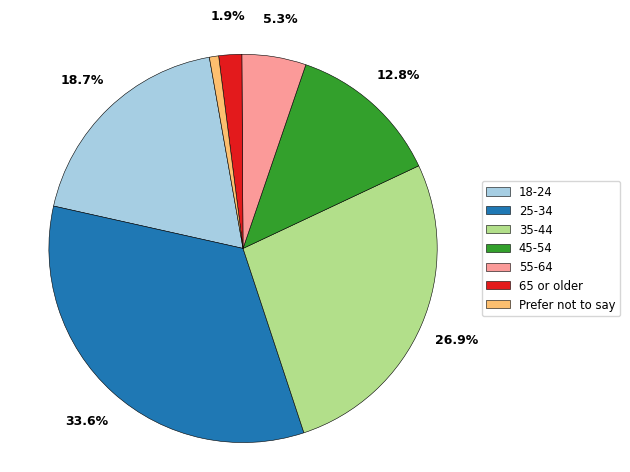

In [357]:
labels = age_groups.index.tolist()
size = age_groups['Proportion']


plt.Figure(figsize=(8, 6))

wedges, texts, autotexts = plt.pie(
    size, 
    autopct='%1.1f%%',
    pctdistance=1.2, 
    startangle=100, 
    colors=plt.cm.Paired.colors,
    wedgeprops=wedge_properties,
    textprops=text_properties
)

# --- New code to hide a specific percentage ---
# Find the index of the label you want to hide
try:
    pnts_index = labels.index('Prefer not to say')
    # Use the index to find the corresponding autotext and set it to an empty string
    autotexts[pnts_index].set_text('')
except ValueError:
    # This will prevent an error if the label is not found
    print("'Prefer not to say' label not found, no changes made.")
# --- End of new code ---

plt.axis('equal')

plt.legend(
    wedges, 
    labels,
    loc='center left',  
    bbox_to_anchor=(1, 0.5), 
    fontsize='small'
)

plt.tight_layout()
plt.show()


## Insights on respondents' coding practices

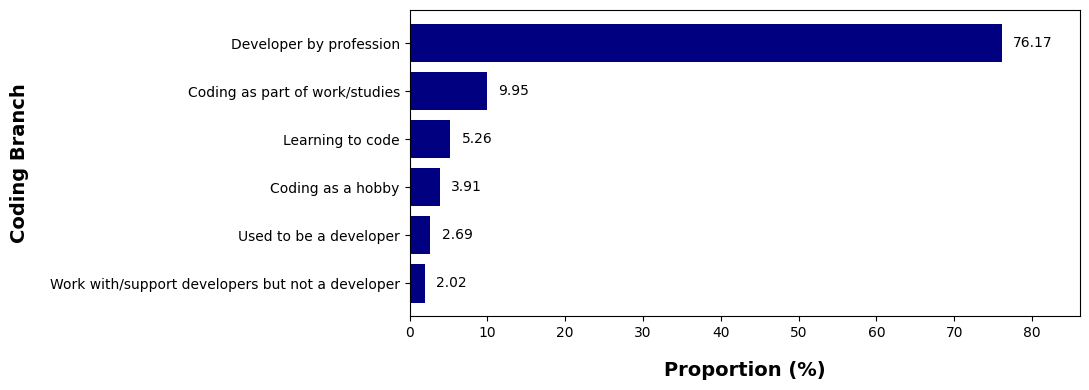

In [382]:
main_branch_new = main_branch_new.sort_values(by='Proportion', ascending=True)

fig, ax = plt.subplots(figsize=(11, 4))

fig = plt.barh(main_branch_new['MainBranch'], main_branch_new['Proportion'], color='navy')

ax.set_xlabel('Proportion (%)', fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel('Coding Branch', fontsize=14, fontweight='bold', labelpad=15)
ax.bar_label(fig, padding=8)
ax.set_xlim(right=main_branch_new['Proportion'].max() + 10)

plt.tight_layout()
plt.show()

## Proportion of Developers by Industry:

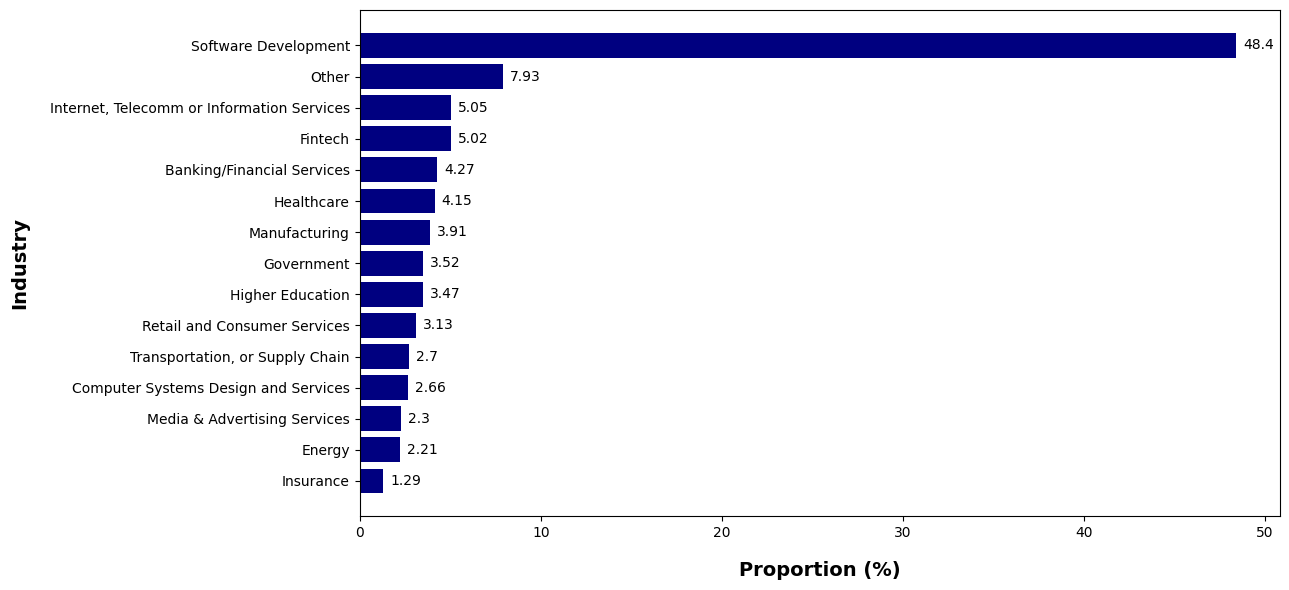

In [380]:
fig, ax = plt.subplots(figsize=(13, 6))

fig = plt.barh(
    industry['Industry'], 
    industry['Proportion'], 
    color='navy'
)

ax.set_xlabel('Proportion (%)', fontsize=14, fontweight='semibold', labelpad=15)
ax.set_ylabel('Industry', fontsize=14, fontweight='semibold', labelpad=15)
ax.bar_label(fig, padding=5, fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.show()


## Which methods does devs use to learn and code AI? ###

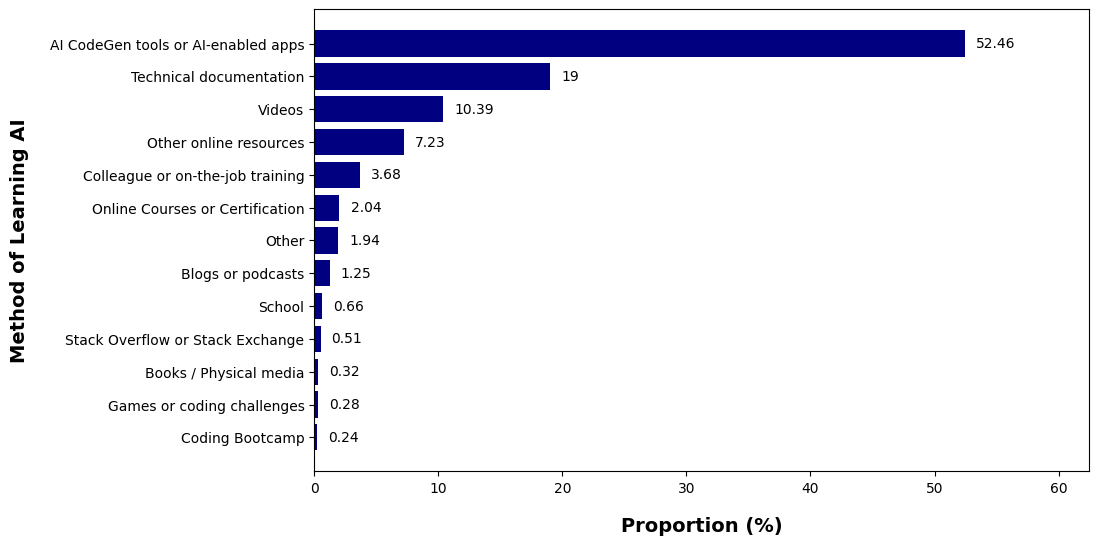

In [358]:
fig, ax = plt.subplots(figsize=(10, 6))

aihow_first_only = aihow_first_only.sort_values(by='Proportion', ascending=True)
fig = plt.barh(aihow_first_only['AILearnHow'], aihow_first_only['Proportion'], color='navy')

ax.set_xlabel('Proportion (%)', fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel('Method of Learning AI', fontsize=14, fontweight='bold', labelpad=15)
ax.bar_label(fig, padding=8)
ax.set_xlim(right=aihow_first_only['Proportion'].max() + 10)

plt.show()